In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df= pd.read_csv('AB_NYC_2019.csv')

In [26]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [28]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [29]:
df.shape

(48895, 16)

##### EDA :- EDA (Exploratory Data Analysis) is the process of analyzing and visualizing data to discover patterns, spot anomalies, and check assumptions before building a machine learning model.

1.Missing values
2.univariate analysis
3.Bivariate analysis
4.correlation between numeric features
5.oulier inspection

In [30]:
# missing values

missing = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [31]:
# target value - room_type

df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

<Axes: xlabel='room_type', ylabel='count'>

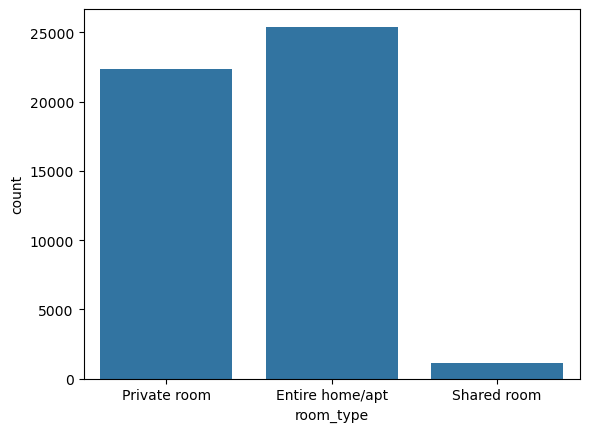

In [32]:
df['room_type'].value_counts()

sns.countplot(x='room_type', data=df)

#### NOTE:- The classes are imbalanced :- shared room are minorty .

In [33]:
# df['room_type'] = df['room_type'].fillna(df['room_type'].median())
df.fillna(df.median(numeric_only=True), inplace=True)

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

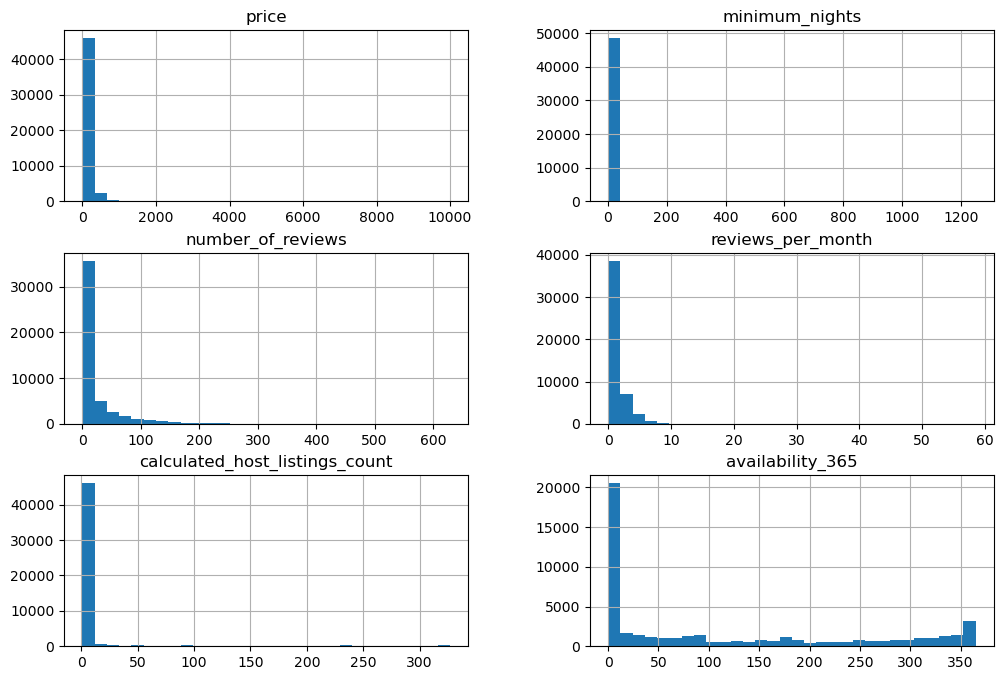

In [34]:
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
#in numerical_cols we will take only that element which are use full
df[numerical_cols].hist(bins=30, figsize=(12,8))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

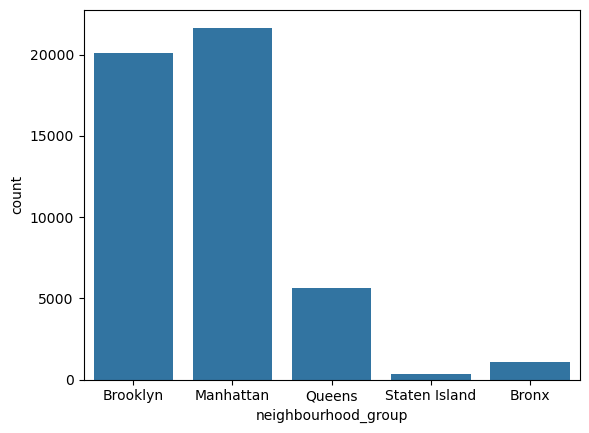

In [35]:
#univariate analysis - categorical features (cannot be done using histograms because it has discrete categories)

sns.countplot(x='neighbourhood_group', data=df)

<Axes: xlabel='room_type', ylabel='price'>

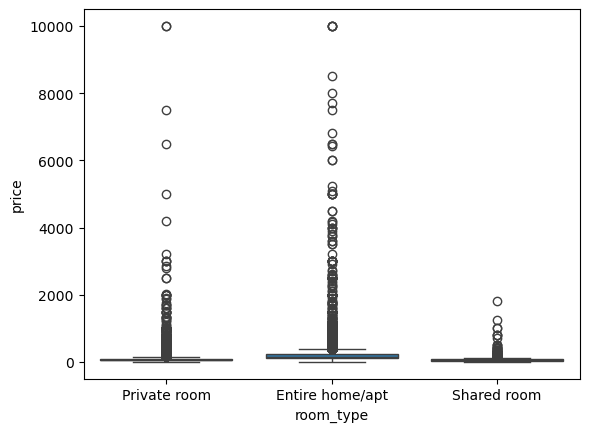

In [36]:
#Bivariate analysis - relationship between two variables (features vs target variable)

sns.boxplot(x='room_type',y='price', data=df)

<Axes: >

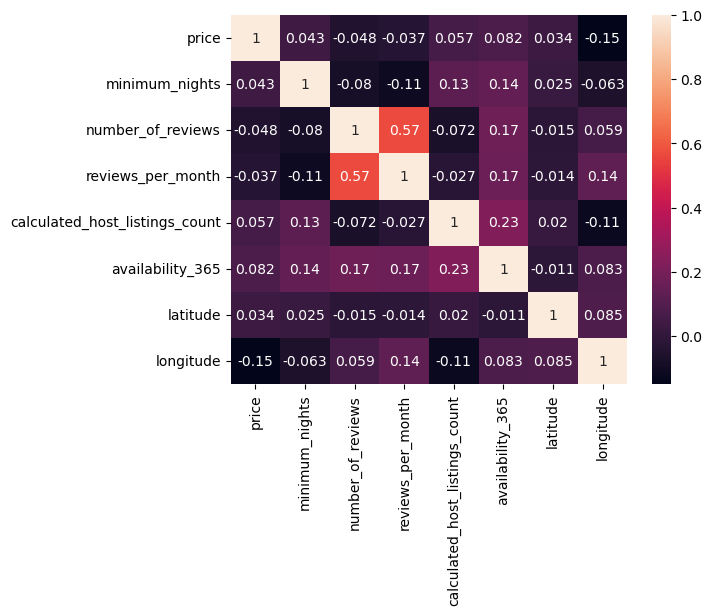

In [37]:
#correlation b/w numeric features

corr = df[numerical_cols + ['latitude','longitude']].corr()
sns.heatmap(corr,annot=True)

In [38]:
# thing of no use id,host_id (not required for model building) and name, host_name (not required for model building)

##### DATA CLEANINIG AND FEATURE ENGINEERING
Steps:
1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a tabular model (id, name, host_id, host_name, last_review).
2. Fill missing reviews_per_month with e (no reviews yet).
3. Cap extreme outliers in price and minimum_nights using percentile clipping, so a handful of data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.
4. Separate features (x) from the target (y).

#### NOTE:-in this data SO OF COLUMNS ARE of no use like host , host _id and many more like this so will will remove all of that to clean up data.

In [39]:
#1. Drop columns that were not helping use
df_clean = df.drop(columns=['id','host_id','name','host_name'])

#2. NO reviews yet-> 0 reviews per month, not missing 
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

#Why is this done?
#In datasets like Airbnb listings, if a property has 0 total reviews, its "reviews per month" metric will often show up as missing (NaN) instead of 0.

In [40]:
#3. Cap Extreme outliers instead of removing them

price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price']= df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights']= df_clean['minimum_nights'].clip(upper=nights_cap)

df_clean

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.72,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,0.72,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,0.72,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,0.72,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,0.72,6,2


In [41]:
#4. Separate features(x) from target(y)

#X = input/features → the information we give to the model
#Y = output/target → the thing we want to predict

x = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

##### Train/Test Split :-(important)
We hold out 20% of the data as a test set that is never touched during model selection or tuning it is only used once, at the very end, to report the final, honest performance. stratify-y keeps the same class proportions in both splits, which matters because the target is imbalanced.

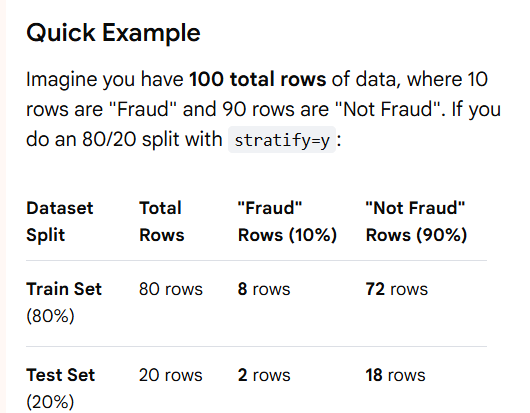

Yes, stratify=y is applied to y (the target variable) only.

NOTE:-
satisfy ye ensure karta hai ki jab bhi hum split ya sample kare, har group(class) ka original propotion maintain rahe.

In [42]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(x,y,test_size=0.2, random_state=42,stratify=y)

##### Preprocessing: Column Transformer + Pipeline :-
##### Data Preprocessing:
Data preprocessing is the process of cleaning and converting raw data into a suitable format for machine learning.

##### Column Transformer:
ColumnTransformer is used to apply different preprocessing techniques to different columns of a dataset.

For example:

Numerical columns → Scaling
Categorical columns → One-Hot Encoding

##### Pipeline:
A Pipeline is used to combine preprocessing steps and the machine learning model into one sequence/workflow.

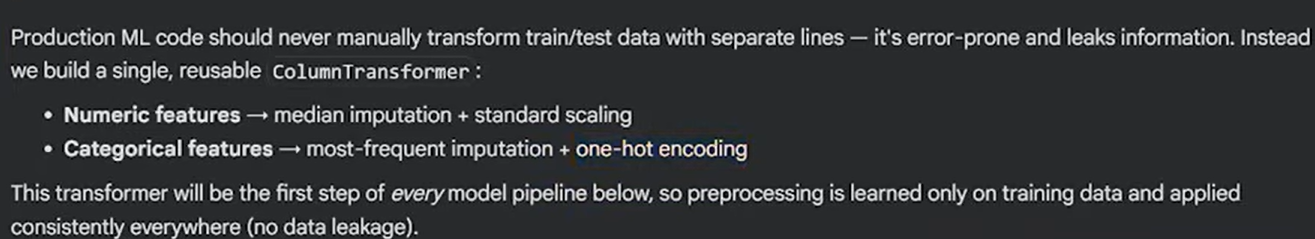

In [43]:
df_clean

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.72,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,0.72,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,0.72,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,0.72,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,0.72,6,2


In [49]:
df_clean[numerical_cols].skew()  # to handle skewness we will use power transformer(because the skewness is more than 0.5)

latitude                          0.237167
longitude                         1.284210
price                             2.776321
minimum_nights                    2.360347
number_of_reviews                 3.690635
reviews_per_month                 3.603699
calculated_host_listings_count    7.933174
availability_365                  0.763408
dtype: float64

In [51]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

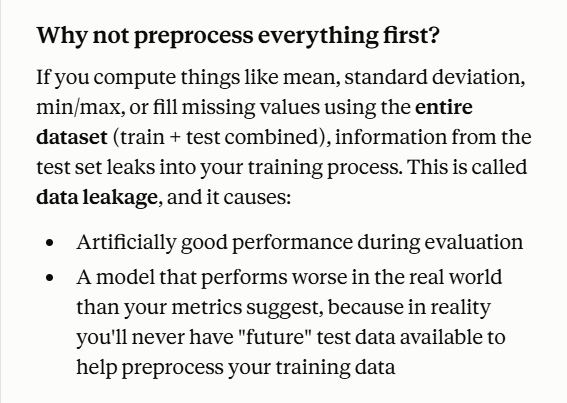

In [ ]:
numerical_cols = ['latitude','longitude','price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

#Categorical features are columns whose values represent categories or groups, rather than numerical measurements.

categorical_cols = ['neighbourhood_group', 'neighbourhood']

#1. Pipline for numerical features
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('skewness', PowerTransformer(method='yeo-johnson')),# deskewing the data(default method is yeo-johnson)
    ('scaler', StandardScaler())])

#2. Pipeline for categorical features
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[("numerical", numerical_pipeline, numerical_cols),
                                              ("categorical", categorical_pipeline, categorical_cols)])
preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


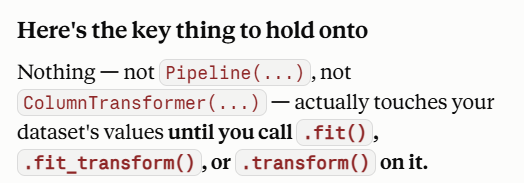